# Proyecto ABP — Entrega Final
## Graficos

Objetivo: ver los resultados del análisis del dataset de forma clara y visual.


In [195]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [196]:
# Carga del dataset limpio
df = pd.read_csv('https://raw.githubusercontent.com/Tec-IA-Proyectos-26/ObraSync_Datos_Alfa/refs/heads/main/DATOS/DATA_BASE_CLEAN.csv')

In [197]:
#revisar que cargo bien el dataset
df.head()

,descripcion,marca,compra_total,ingreso_total,pendiente,estado,fecha,año
0,ESPATULA PINTOR LAMINADA CABO PLASTICO - 50 MM,BIASSONI,36.0,1.0,36.0,INCOMPLETO,2026-01-29,2026
1,AEROSOL SMART PAINT AA BLANCO BRILLANTE 350ML...,DOBLE A - AE,72.0,72.0,0.0,FULL,2026-01-29,2026
2,PANTALON CARGO DEL NORTE MUJER - PAMPERO VERDE...,PAMPERO,2.0,1.0,2.0,INCOMPLETO,2026-01-29,2026
3,REGULADOR GLP C/1 MAN. (PROP. Y OTROS),FERROLAN,15.0,15.0,0.0,FULL,2026-01-29,2026
4,AEROSOL USO GENERAL NEGRO MATE 250 GR,TEKBOND,60.0,1.0,60.0,INCOMPLETO,2026-01-29,2026


## Analisis de la variable - Estado

Como se reparten los pedidos entre FULL (completo), PARCIAL(pendientes) e INCOMPLETO (sin entregas).

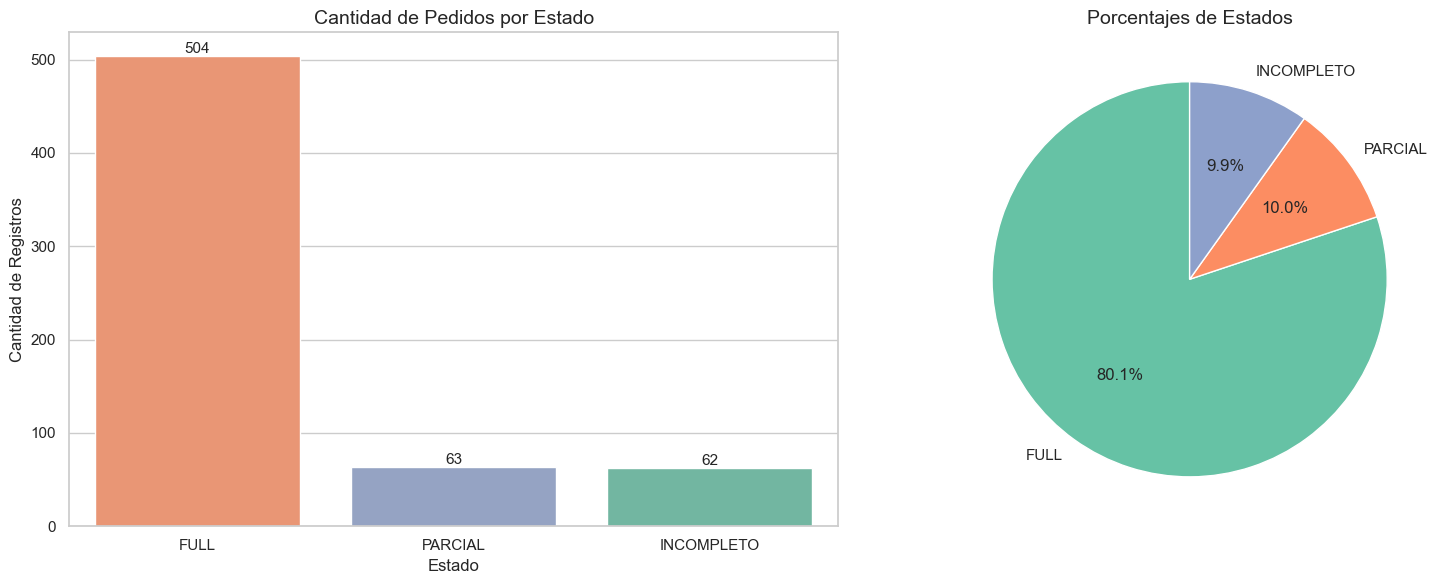

In [198]:
#para mostrar dos graficos juntos se usa subplots con 1 fila,2 columnas y se ajusta el tamaño
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Cantidad de registros por estado
# con patches se obtiene cada barra del grafico para luego anotarle el valor encima
orden = df['estado'].value_counts().index
sns.countplot(data=df, x='estado', order=orden, hue='estado', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Cantidad de Pedidos por Estado', fontsize=14)
axes[0].set_xlabel('Estado')
axes[0].set_ylabel('Cantidad de Registros')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Porcentaje de cada estado
#se uso autopct para mostrar el porcentaje en el grafico
#startangle para rotar el grafico y wedgeprops para darle borde blanco a cada porcion del grafico
conteo = df['estado'].value_counts()
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'),
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Porcentajes de Estados', fontsize=14)

plt.tight_layout()
plt.show()


## Top de Articulos por fecha

Identificamos los productos ("descripcion") con mayor volumen de compra y como evoluciona la compra total a lo largo de las fechas registradas.

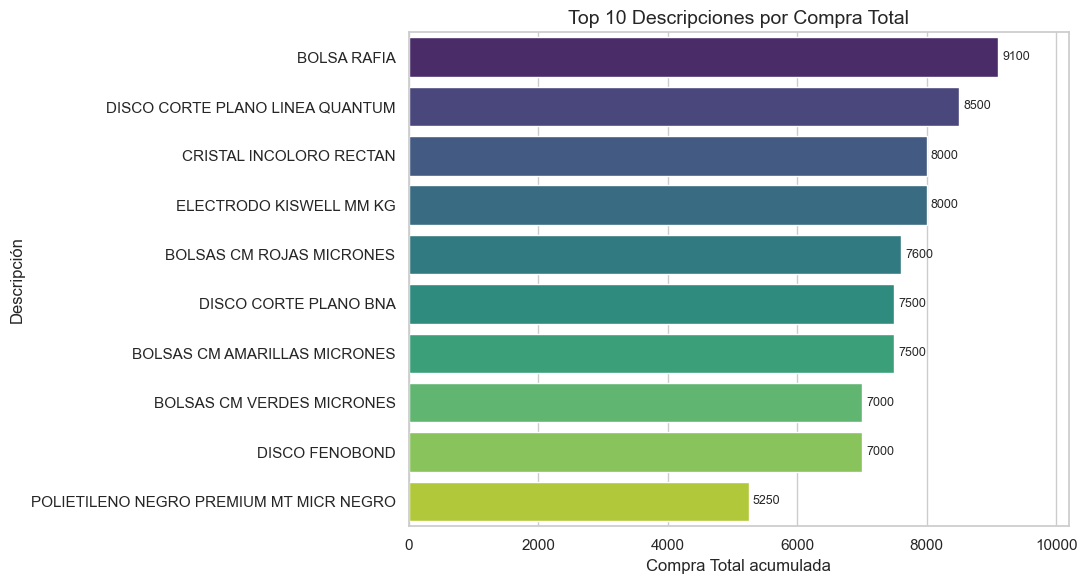

In [199]:
# descripciones por compra_total acumulada
top_desc = df.groupby('descripcion')['compra_total'].sum().sort_values(ascending=False).head(10)

# Acortamos los nombres largos para que el grafico quede bien encuadrado
#quitar medidas y numero y si aparece X tambien, quitarlas asi solo queda las descripciones principales,sin los numeros 
# se uso Regex para dejar la descripcion principal sin los numeros ni medidas

def acortar_descripcion(desc):
    # Eliminar números, medidas y caracteres especiales
    desc = re.sub(r'[\dXx]+', '', desc)  # Elimina numeros y 'X'
    desc = re.sub(r'[^\w\s]', '', desc)  # Elimina caracteres especiales
    desc = re.sub(r'\s+', ' ', desc)  # Elimina espacios extra
    return desc.strip()

etiquetas = top_desc.index.map(acortar_descripcion)

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=top_desc.values, y=etiquetas, hue=etiquetas, palette='viridis', legend=False)
ax.set_title('Top 10 Descripciones por Compra Total', fontsize=14)
ax.set_xlabel('Compra Total acumulada')
ax.set_ylabel('Descripción')
ax.margins(x=0.12)  # espacio a la derecha para que no se corten los valores
for p in ax.patches:
    ax.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9, xytext=(3, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

# Evolucion de compra total por fecha

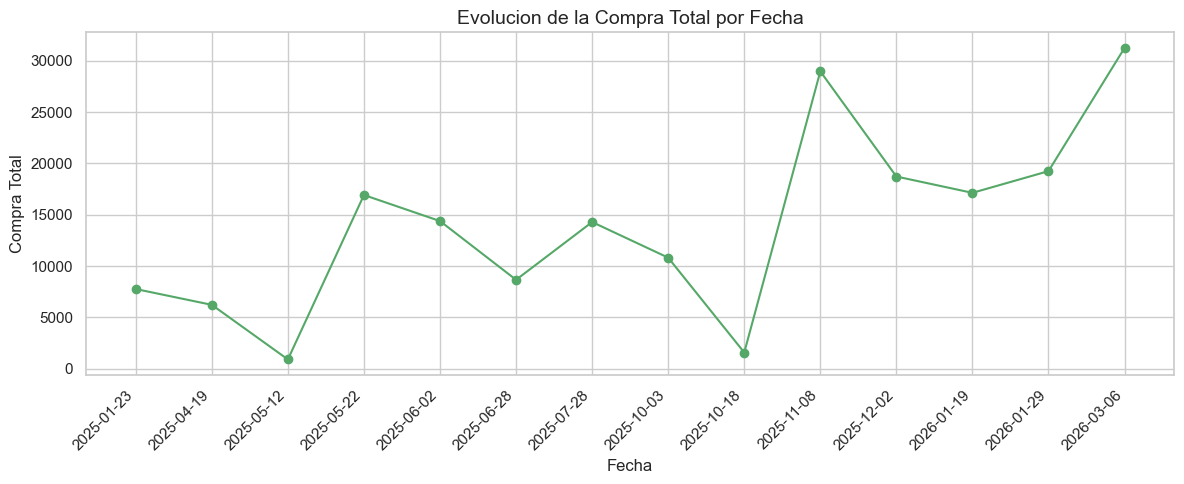

In [200]:
# Evolucion de la compra total por fecha
# se agrua con groupby por fecha y se suma la compra total, luego se ordena por fecha para que el grafico quede cronologico
compra_por_fecha = df.groupby('fecha')['compra_total'].sum().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(compra_por_fecha.index, compra_por_fecha.values, marker='o', color='#55A868')
plt.title('Evolucion de la Compra Total por Fecha', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Compra Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Resumen general del proyecto

El presente proyecto analizo el dataset ObraSync, compuesto por 629 registros y 8 variables, que describen las compras de materiales de obra, su ingreso fisico y los saldos pendientes durante el año 2026 y 2025.
El dataset se encuentra completamente limpio, sin valores nulos, lo que garantiza la confiabilidad de los resultados.

Estado de los pedidos: La gran mayoria de los pedidos se encuentra en estado FULL (504 registros, 80%), es decir, ingresaron por completo. Sin embargo, una proporcion quedo en estado PARCIAL o INCOMPLETO, lo que representa material comprado que aún no llego a la obra y constituye una alerta operativa para el control de stock.

Se puede ver como evoluciona la actividad de compra a lo largo de las fechas. Esto facilita detectar los materiales criticos y los picos de demanda en el tiempo.